# Phase 3 - Programmed Driver Inputs

> Project Chrono / Vehicle / Driver  
> 예제 목적: 시간 함수로 `steering`, `throttle`, `braking`을 직접 만들어 HMMWV에 넣고 차량 응답을 비교한다.

---

## 0. 이 예제에서 배우는 것

이 노트북은 Chrono의 driver subsystem을 가장 단순한 방식으로 이해하기 위한 예제이다.

Interactive Driver처럼 사람이 직접 조작하지 않고, 코드에서 다음 입력을 직접 생성한다.

```text
DriverInputs
 ├─ m_steering
 ├─ m_throttle
 └─ m_braking
```

그리고 이 입력을 매 timestep마다 차량에 전달한다.

```text
programmed input
    ↓
hmmwv.Synchronize(time, driver_inputs, terrain)
    ↓
vehicle dynamics
    ↓
CSV + graph
```

---

## 1. 실험 Case

| Case | 의미 |
|---|---|
| `constant_throttle` | 일정 throttle로 직진 |
| `step_steering` | 3초 이후 steering step 입력 |
| `sine_steering` | sinusoidal steering 입력 |
| `throttle_ramp` | throttle을 시간에 따라 서서히 증가 |

이 실험의 핵심은 **driver input profile이 차량 궤적과 속도에 어떤 차이를 만드는지 확인하는 것**이다.


## 2. Import

PyChrono, NumPy, Pandas, Matplotlib을 불러온다.

- `pychrono`: Chrono 기본 물리 엔진
- `pychrono.vehicle`: Chrono::Vehicle 모듈
- `pandas`: CSV 저장 및 데이터 분석
- `matplotlib`: 그래프 출력


In [3]:
import math as m
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pychrono as chrono
import pychrono.vehicle as veh

print("Chrono import success")
print("NumPy version:", np.__version__)


Chrono import success
NumPy version: 1.26.4


## 3. 결과 저장 경로 설정

프로젝트 루트를 자동으로 찾고, 결과를 아래 폴더에 저장한다.

```text
results/phase3/driver_programmed_inputs/
 ├─ *.csv
 └─ figures/
```


In [4]:
def find_project_root(start=None):
    if start is None:
        start = Path.cwd()
    start = Path(start).resolve()

    for p in [start] + list(start.parents):
        if (p / ".git").exists() or (p / "docs").exists():
            return p

    return start


PROJECT_ROOT = find_project_root()
RESULT_DIR = PROJECT_ROOT / "results" / "phase3" / "driver_programmed_inputs"
FIGURE_DIR = RESULT_DIR / "figures"

RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULT_DIR:", RESULT_DIR)
print("FIGURE_DIR:", FIGURE_DIR)


PROJECT_ROOT: C:\Project_Chrono\Project_Chrono_Practice
RESULT_DIR: C:\Project_Chrono\Project_Chrono_Practice\results\phase3\driver_programmed_inputs
FIGURE_DIR: C:\Project_Chrono\Project_Chrono_Practice\results\phase3\driver_programmed_inputs\figures


## 4. 시뮬레이션 기본 파라미터

이번 실험에서는 모든 case에서 차량/지형 조건을 동일하게 유지하고, **driver input만 바꾼다.**

| 항목 | 값 |
|---|---|
| Vehicle | HMMWV_Reduced |
| Terrain | Flat RigidTerrain |
| Tire | TMeasy |
| Driveline | AWD |
| Simulation time | 12 s |
| Visualization | 없음, Headless |


In [5]:
# Chrono Vehicle Y-up world frame
veh.ChWorldFrame.SetYUP()

# Contact / tire / powertrain settings
contact_method = chrono.ChContactMethod_NSC
tire_model = veh.TireModelType_TMEASY

# Simulation setting
step_size = 3e-3
tire_step_size = 1e-3
t_end = 12.0
terrain_friction = 0.9

# Driver input cases
driver_cases = [
    {"case_name": "constant_throttle", "mode": "constant_throttle"},
    {"case_name": "step_steering", "mode": "step_steering"},
    {"case_name": "sine_steering", "mode": "sine_steering"},
    {"case_name": "throttle_ramp", "mode": "throttle_ramp"},
]

print("Simulation parameters ready")


Simulation parameters ready


## 5. Helper Functions

여기서는 차량 상태를 읽고, driver input을 생성하고, 후처리 지표를 계산하는 보조 함수를 만든다.

주요 함수:

| 함수 | 역할 |
|---|---|
| `programmed_inputs()` | 시간과 mode에 따라 driver input 생성 |
| `log_vehicle_state()` | 차량 위치, 속도, 자세, 입력값 저장 |
| `add_derived_metrics()` | acceleration, yaw_rate 계산 |


In [6]:
def get_chassis_body(hmmwv):
    """HMMWV wrapper에서 chassis body를 안전하게 가져온다."""
    vehicle = hmmwv.GetVehicle()

    if hasattr(vehicle, "GetChassisBody"):
        return vehicle.GetChassisBody()

    if hasattr(vehicle, "GetChassis"):
        chassis = vehicle.GetChassis()
        if hasattr(chassis, "GetBody"):
            return chassis.GetBody()

    raise RuntimeError("Could not access chassis body.")


def safe_get_rpy_from_body(body):
    """차체 quaternion에서 roll, pitch, yaw를 얻는다. API 차이가 있으면 NaN으로 둔다."""
    try:
        angles = body.GetRot().GetCardanAnglesXYZ()
        return float(angles.x), float(angles.y), float(angles.z)
    except Exception:
        return np.nan, np.nan, np.nan


def get_vehicle_speed(hmmwv, body):
    """vehicle API가 있으면 speed를 직접 읽고, 없으면 velocity norm으로 계산한다."""
    try:
        return float(hmmwv.GetVehicle().GetSpeed())
    except Exception:
        vel = body.GetPosDt()
        return float((vel.x**2 + vel.y**2 + vel.z**2) ** 0.5)


def programmed_inputs(time, mode):
    """
    시간과 실험 mode에 따라 DriverInputs를 생성한다.

    mode:
        constant_throttle : 일정 throttle 직진
        step_steering     : 3초 이후 steering step 입력
        sine_steering     : sinusoidal steering 입력
        throttle_ramp     : throttle을 시간에 따라 증가
    """
    inputs = veh.DriverInputs()

    if mode == "constant_throttle":
        steering = 0.0
        throttle = 0.4
        braking = 0.0

    elif mode == "step_steering":
        steering = 0.0 if time < 3.0 else 0.3
        throttle = 0.4
        braking = 0.0

    elif mode == "sine_steering":
        steering = 0.25 * np.sin(2 * np.pi * 0.25 * time)
        throttle = 0.4
        braking = 0.0

    elif mode == "throttle_ramp":
        steering = 0.0
        throttle = min(0.6, 0.08 * time)
        braking = 0.0

    else:
        steering, throttle, braking = 0.0, 0.0, 0.0

    # Chrono DriverInputs의 정상 범위로 제한한다.
    inputs.m_steering = float(np.clip(steering, -1.0, 1.0))
    inputs.m_throttle = float(np.clip(throttle, 0.0, 1.0))
    inputs.m_braking = float(np.clip(braking, 0.0, 1.0))

    return inputs


def log_vehicle_state(hmmwv, driver_inputs, case_name):
    """현재 timestep의 차량 상태와 driver input을 dictionary로 저장한다."""
    body = get_chassis_body(hmmwv)
    time = float(hmmwv.GetSystem().GetChTime())

    pos = body.GetPos()
    vel = body.GetPosDt()
    roll, pitch, yaw = safe_get_rpy_from_body(body)
    speed = get_vehicle_speed(hmmwv, body)

    return {
        "case_name": case_name,
        "time": time,

        # Y-up coordinate: X forward, Y vertical, Z lateral
        "x": float(pos.x),
        "y": float(pos.y),
        "z": float(pos.z),

        "vx": float(vel.x),
        "vy": float(vel.y),
        "vz": float(vel.z),

        "speed": speed,
        "roll": roll,
        "pitch": pitch,
        "yaw": yaw,

        "steering": float(driver_inputs.m_steering),
        "throttle": float(driver_inputs.m_throttle),
        "braking": float(driver_inputs.m_braking),
    }


def add_derived_metrics(df_case):
    """저장된 time history로부터 acceleration과 yaw_rate를 계산한다."""
    df_case = df_case.copy()
    time = df_case["time"].to_numpy()
    speed = df_case["speed"].to_numpy()

    if len(time) >= 2:
        df_case["acceleration"] = np.gradient(speed, time)
        yaw = np.unwrap(df_case["yaw"].to_numpy())
        df_case["yaw_rate"] = np.gradient(yaw, time)
    else:
        df_case["acceleration"] = np.nan
        df_case["yaw_rate"] = np.nan

    return df_case


print("Helper functions ready")


Helper functions ready


## 6. 한 개 Case 실행 함수

`run_driver_case()`는 한 개 driver input profile을 실행하는 함수이다.

매 case마다 새 HMMWV와 terrain을 생성하는 이유:

```text
case 간 초기 조건을 완전히 동일하게 유지하기 위해서
```

함수 내부 흐름:

```text
HMMWV 생성
→ RigidTerrain 생성
→ time loop
→ programmed_inputs(time, mode)
→ Synchronize / Advance
→ DataFrame 반환
```


In [7]:
def run_driver_case(case_name, mode):
    """한 개 programmed driver case를 실행하고 DataFrame을 반환한다."""

    initLoc = chrono.ChVector3d(0, 1, 10)
    initYaw = 0.0

    # 1. Vehicle 생성
    hmmwv = veh.HMMWV_Reduced()

    hmmwv.SetContactMethod(contact_method)
    hmmwv.SetChassisCollisionType(veh.CollisionType_NONE)
    hmmwv.SetChassisFixed(False)
    hmmwv.SetInitPosition(chrono.ChCoordsysd(initLoc, chrono.QuatFromAngleY(initYaw)))

    hmmwv.SetEngineType(veh.EngineModelType_SIMPLE)
    hmmwv.SetTransmissionType(veh.TransmissionModelType_AUTOMATIC_SIMPLE_MAP)
    hmmwv.SetDriveType(veh.DrivelineTypeWV_AWD)
    hmmwv.SetTireType(tire_model)
    hmmwv.SetTireStepSize(tire_step_size)

    hmmwv.Initialize()
    hmmwv.GetSystem().SetCollisionSystemType(chrono.ChCollisionSystem.Type_BULLET)

    # 2. Terrain 생성
    terrain = veh.RigidTerrain(hmmwv.GetSystem())

    patch_mat = chrono.ChContactMaterialNSC()
    patch_mat.SetFriction(terrain_friction)

    terrain.AddPatch(
        patch_mat,
        chrono.ChCoordsysd(chrono.VNULL, chrono.QuatFromAngleX(-m.pi / 2)),
        200.0,
        100.0
    )

    terrain.Initialize()

    # 3. Simulation loop
    log_rows = []

    while hmmwv.GetSystem().GetChTime() < t_end:
        time = hmmwv.GetSystem().GetChTime()

        # 시간 함수 기반 driver input 생성
        driver_inputs = programmed_inputs(time, mode)

        # 현재 상태 저장
        log_rows.append(log_vehicle_state(hmmwv, driver_inputs, case_name))

        # 현재 시간에서 subsystem 정보 동기화
        terrain.Synchronize(time)
        hmmwv.Synchronize(time, driver_inputs, terrain)

        # timestep만큼 전진
        terrain.Advance(step_size)
        hmmwv.Advance(step_size)

    df_case = pd.DataFrame(log_rows)
    return add_derived_metrics(df_case)


print("run_driver_case() ready")


run_driver_case() ready


## 7. 모든 Case 실행 및 CSV 저장

각 driver case를 실행하고 개별 CSV와 통합 CSV를 저장한다.


In [8]:
all_dfs = []

for case in driver_cases:
    print("Running:", case["case_name"])

    df_case = run_driver_case(case["case_name"], case["mode"])

    case_csv_path = RESULT_DIR / f'{case["case_name"]}.csv'
    df_case.to_csv(case_csv_path, index=False, encoding="utf-8-sig")
    print("Saved:", case_csv_path)

    all_dfs.append(df_case)

df = pd.concat(all_dfs, ignore_index=True)

all_csv_path = RESULT_DIR / "programmed_driver_all_cases.csv"
df.to_csv(all_csv_path, index=False, encoding="utf-8-sig")

print("Saved combined CSV:", all_csv_path)
display(df.head())
display(df.tail())


Running: constant_throttle
Saved: C:\Project_Chrono\Project_Chrono_Practice\results\phase3\driver_programmed_inputs\constant_throttle.csv
Running: step_steering
Saved: C:\Project_Chrono\Project_Chrono_Practice\results\phase3\driver_programmed_inputs\step_steering.csv
Running: sine_steering
Saved: C:\Project_Chrono\Project_Chrono_Practice\results\phase3\driver_programmed_inputs\sine_steering.csv
Running: throttle_ramp
Saved: C:\Project_Chrono\Project_Chrono_Practice\results\phase3\driver_programmed_inputs\throttle_ramp.csv
Saved combined CSV: C:\Project_Chrono\Project_Chrono_Practice\results\phase3\driver_programmed_inputs\programmed_driver_all_cases.csv


,case_name,time,x,y,z,vx,vy,vz,speed,roll,pitch,yaw,steering,throttle,braking,acceleration,yaw_rate
0,constant_throttle,0.000,0.056000,1.213000,10.0,0.000000,0.000000,0.000000e+00,0.000000,-1.570796,0.000000e+00,0.000000,0.0,0.4,0.0,-1.351101,-0.028312
1,constant_throttle,0.003,0.056006,1.212908,10.0,0.001975,-0.030634,-6.863038e-07,-0.004053,-1.570797,-7.627943e-10,-0.000085,0.0,0.4,0.0,-0.696926,-0.029179
2,constant_throttle,0.006,0.056013,1.212716,10.0,0.002207,-0.063879,-2.397985e-06,-0.004182,-1.570797,-1.722348e-09,-0.000175,0.0,0.4,0.0,0.039788,-0.029090
3,constant_throttle,0.009,0.056019,1.212433,10.0,0.002153,-0.094368,-1.010458e-05,-0.003815,-1.570800,-1.003126e-08,-0.000259,0.0,0.4,0.0,0.120617,-0.027140
4,constant_throttle,0.012,0.056025,1.212061,10.0,0.002069,-0.124009,-3.576578e-05,-0.003458,-1.570806,-2.787842e-08,-0.000338,0.0,0.4,0.0,0.121106,-0.025101


,case_name,time,x,y,z,vx,vy,vz,speed,roll,pitch,yaw,steering,throttle,braking,acceleration,yaw_rate
15995,throttle_ramp,11.985,81.213014,0.631663,9.901054,13.854318,-0.000035,-0.030815,13.851641,-1.571231,0.002226,-0.019729,0.0,0.6,0.0,0.634801,-0.000073
15996,throttle_ramp,11.988,81.254582,0.631663,9.900961,13.856222,-0.000035,-0.030786,13.853545,-1.571232,0.002227,-0.019729,0.0,0.6,0.0,0.634893,-0.000069
15997,throttle_ramp,11.991,81.296157,0.631663,9.900869,13.858127,-0.000037,-0.030777,13.855450,-1.571232,0.002229,-0.019730,0.0,0.6,0.0,0.635748,-0.000065
15998,throttle_ramp,11.994,81.337737,0.631663,9.900776,13.860035,-0.000038,-0.030795,13.857359,-1.571232,0.002230,-0.019730,0.0,0.6,0.0,0.636886,-0.000059
15999,throttle_ramp,11.997,81.379323,0.631663,9.900684,13.861946,-0.000037,-0.030839,13.859271,-1.571232,0.002231,-0.019730,0.0,0.6,0.0,0.637393,-0.000055


## 8. Speed Response 비교

driver input profile에 따라 차량 속도 응답이 어떻게 달라지는지 확인한다.


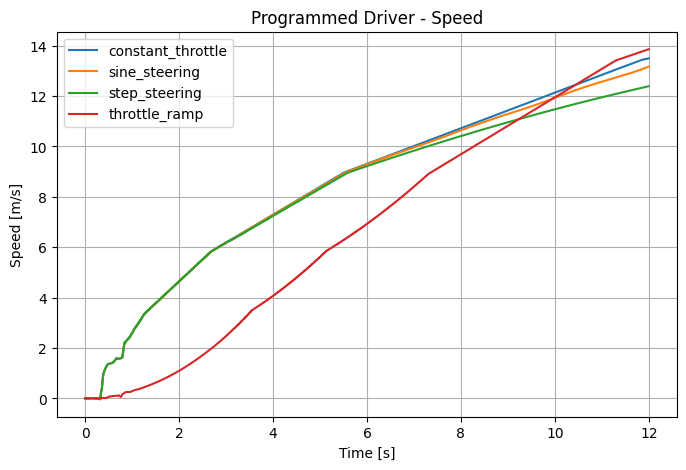

Saved figure: C:\Project_Chrono\Project_Chrono_Practice\results\phase3\driver_programmed_inputs\figures\programmed_driver_speed.png


In [9]:
plt.figure(figsize=(8, 5))

for case_name, df_case in df.groupby("case_name"):
    plt.plot(df_case["time"], df_case["speed"], label=case_name)

plt.xlabel("Time [s]")
plt.ylabel("Speed [m/s]")
plt.title("Programmed Driver - Speed")
plt.grid(True)
plt.legend()

fig_path = FIGURE_DIR / "programmed_driver_speed.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)


## 9. Trajectory 비교

X-Z 평면에서 차량의 주행 궤적을 비교한다.  
Y-up 좌표계에서 X는 전방, Z는 횡방향이다.


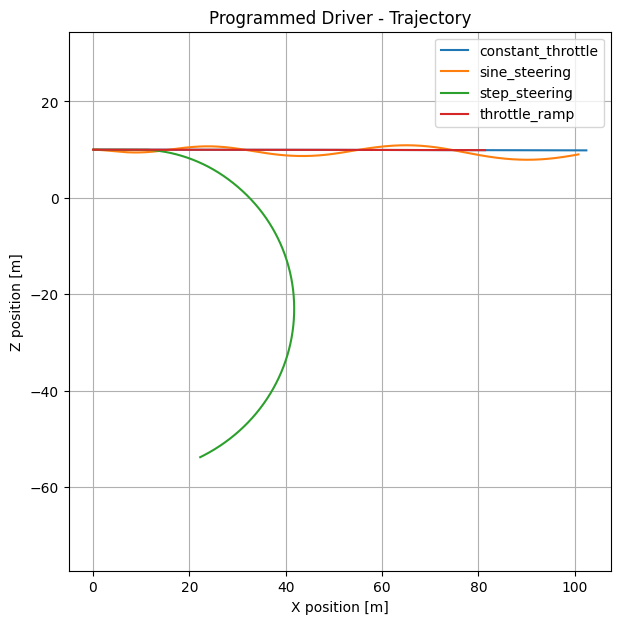

Saved figure: C:\Project_Chrono\Project_Chrono_Practice\results\phase3\driver_programmed_inputs\figures\programmed_driver_trajectory.png


In [10]:
plt.figure(figsize=(7, 7))

for case_name, df_case in df.groupby("case_name"):
    plt.plot(df_case["x"], df_case["z"], label=case_name)

plt.xlabel("X position [m]")
plt.ylabel("Z position [m]")
plt.title("Programmed Driver - Trajectory")
plt.axis("equal")
plt.grid(True)
plt.legend()

fig_path = FIGURE_DIR / "programmed_driver_trajectory.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)


## 10. Driver Input 비교

입력 profile 자체를 확인한다.  
결과 그래프를 해석할 때 반드시 입력 그래프와 함께 봐야 한다.


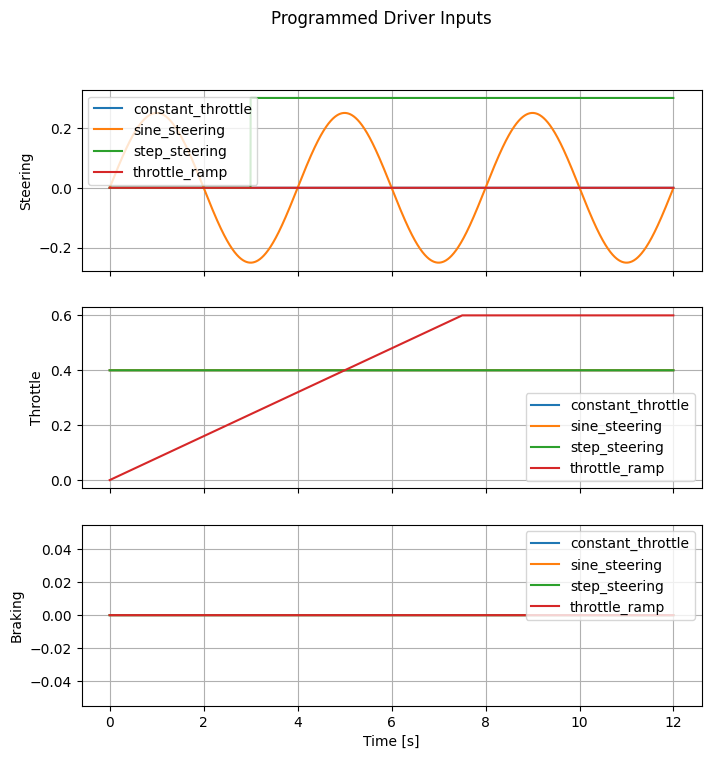

Saved figure: C:\Project_Chrono\Project_Chrono_Practice\results\phase3\driver_programmed_inputs\figures\programmed_driver_inputs.png


In [11]:
fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

for case_name, df_case in df.groupby("case_name"):
    axes[0].plot(df_case["time"], df_case["steering"], label=case_name)
    axes[1].plot(df_case["time"], df_case["throttle"], label=case_name)
    axes[2].plot(df_case["time"], df_case["braking"], label=case_name)

axes[0].set_ylabel("Steering")
axes[1].set_ylabel("Throttle")
axes[2].set_ylabel("Braking")
axes[2].set_xlabel("Time [s]")

for ax in axes:
    ax.grid(True)
    ax.legend()

fig.suptitle("Programmed Driver Inputs")

fig_path = FIGURE_DIR / "programmed_driver_inputs.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)


## 11. Summary Metrics

case별 이동 거리, 평균 속도, 최대 속도, yaw rate 등을 정리한다.


In [13]:
summary_rows = []

for case_name, df_case in df.groupby("case_name"):
    summary_rows.append({
        "case_name": case_name,
        "travel_x_m": df_case["x"].iloc[-1] - df_case["x"].iloc[0],
        "travel_z_m": df_case["z"].iloc[-1] - df_case["z"].iloc[0],
        "mean_speed_mps": df_case["speed"].mean(),
        "max_speed_mps": df_case["speed"].max(),
        "mean_abs_yaw_rate_radps": df_case["yaw_rate"].abs().mean(),
        "max_abs_steering": df_case["steering"].abs().max(),
        "max_throttle": df_case["throttle"].max(),
        "max_braking": df_case["braking"].max(),
    })

summary_df = pd.DataFrame(summary_rows)

summary_path = RESULT_DIR / "programmed_driver_summary.csv"
summary_df.to_csv(summary_path, index=False, encoding="utf-8-sig")

print("Saved summary:", summary_path)
display(summary_df)


Saved summary: C:\Project_Chrono\Project_Chrono_Practice\results\phase3\driver_programmed_inputs\programmed_driver_summary.csv


,case_name,travel_x_m,travel_z_m,mean_speed_mps,max_speed_mps,mean_abs_yaw_rate_radps,max_abs_steering,max_throttle,max_braking
0,constant_throttle,102.359288,-0.143907,8.527193,13.495987,0.018105,0.00,0.4,0.0
1,sine_steering,100.707413,-0.982412,8.443290,13.168637,0.018397,0.25,0.4,0.0
2,step_steering,22.213617,-63.821113,8.253809,12.389768,0.276298,0.30,0.4,0.0
3,throttle_ramp,81.323323,-0.099316,6.775129,13.859271,0.011529,0.00,0.6,0.0


## 12. 결과 해석 가이드


```text
constant_throttle:
    steering 입력이 없으므로 거의 직진하며, 속도 응답은 throttle에 의해 결정된다.

step_steering:
    3초 이후 steering 입력이 들어가면서 yaw rate와 횡방향 이동이 증가한다.

sine_steering:
    steering이 주기적으로 변하므로 차량 궤적도 좌우로 흔들리는 형태가 나타난다.

throttle_ramp:
    throttle이 서서히 증가하므로 초기 가속이 더 완만하게 나타난다.
```


```text
Driver input profile을 코드로 정의하면 동일한 차량/지형 조건에서 반복 가능한 제어 입력 실험을 수행할 수 있다.
이는 이후 tire, terrain, driveline 조건 비교 및 강화학습 action 설계의 기초가 된다.
```
